# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV109"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv109')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv109/lv109-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV109,gene_band
0,ASAP2,8.104216,2p25.1
1,SEC14L2,7.993783,22q12.2
2,MRPL40,7.954603,22q11.21
3,GHITM,7.194781,10q23.1
4,RAC1,5.709713,7p22.1
5,CXCR5,5.296248,NaN
6,PSME1,4.696085,14q12
7,CNOT8,4.110997,5q33.2
8,EHMT2,3.735834,6p21.33
9,TPM4,3.365018,19p13.12


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:31:16,723 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:31:16,723 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP033135, SRP042161, SRP043339, SRP055569, SRP060416, SRP057196, SRP012461, SRP009266, SRP007338, SRP066834, SRP063840, SRP003754, SRP009862, SRP005279, SRP050499, SRP012056, SRP058773, SRP057205, SRP019272, SRP059775, SRP014428, SRP025982, SRP055153, SRP059170, SRP037982, SRP002326, SRP056049, SRP057852, SRP040577, SRP020486, SRP060715, SRP059732, SRP059733, SRP033566, SRP034712, SRP055390, SRP007947, SRP064464, SRP029513, SRP059035, SRP018837, SRP055810, SRP018838, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (39 != 43)
  warnings.warn(


In [12]:
lv_data.shape

(7755, 85)

In [13]:
lv_data.head()

cell type  \
project   run                                                  
SRP033135 SRR1032910  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032911  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032912  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032913  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032914  Human Skeletal Muscle Myoblasts (HSMM)   

                     hour post serum-switch debris control well cells in well  \
project   run                                                                   
SRP033135 SRR1032910                      0  FALSE        FALSE             1   
          SRR1032911                      0  FALSE        FALSE             1   
          SRR1032912                      0  FALSE        FALSE             1   
          SRR1032913                      0  FALSE        FALSE             2   
          SRR1032914                      0  FALSE        FALSE             1   

                     library protocol cell line patient id subtype  \
project   run                                                        
SRP033135 SRR1032910      Single-cell       NaN        NaN     NaN   
          SRR1032911      Single-cell       NaN        NaN     NaN   
          SRR1032912      Single-cell       NaN        NaN     NaN   
          SRR1032913      Single-cell       NaN        NaN     NaN   
          SRR1032914      Single-cell       NaN        NaN     NaN   

                     t cell type  ... cell count ercc_mix ercc_dilution  \
project   run                     ...                                     
SRP033135 SRR1032910         NaN  ...        NaN      NaN           NaN   
          SRR1032911         NaN  ...        NaN      NaN           NaN   
          SRR1032912         NaN  ...        NaN      NaN           NaN   
          SRR1032913         NaN  ...        NaN      NaN           NaN   
          SRR1032914         NaN  ...        NaN      NaN           NaN   

                     antibody crosslinker and crosslinking wavelength  \
project   run                                                           
SRP033135 SRR1032910      NaN                                     NaN   
          SRR1032911      NaN                                     NaN   
          SRR1032912      NaN                                     NaN   
          SRR1032913      NaN                                     NaN   
          SRR1032914      NaN                                     NaN   

                     immunoprecipitated protein lineage embryo number  \
project   run                                                           
SRP033135 SRR1032910                        NaN     NaN           NaN   
          SRR1032911                        NaN     NaN           NaN   
          SRR1032912                        NaN     NaN           NaN   
          SRR1032913                        NaN     NaN           NaN   
          SRR1032914                        NaN     NaN           NaN   

                     labexpid     LV109  
project   run                            
SRP033135 SRR1032910      NaN  0.011422  
          SRR1032911      NaN  0.002683  
          SRR1032912      NaN  0.007765  
          SRR1032913      NaN -0.003760  
          SRR1032914      NaN  0.002645  

[5 rows x 85 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

library protocol                  0.520586
debris                            0.520586
hour post serum-switch            0.520586
cells in well                     0.520586
control well                      0.520586
cell type                         0.051969
t cell type                       0.011698
cell surface markers              0.011698
library type                      0.003053
read length                       0.003053
tonsil donor                      0.001687
facs gating                       0.001687
patient id                        0.001344
c1 chip id                        0.001014
experiment_sample_name            0.001014
tissue                            0.000849
well number                       0.000832
reprogramming time point (day)    0.000832
Stage                             0.000801
age                               0.000758
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell type    0.051969
tissue       0.000849
cell line    0.000356
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [17]:
lv_attrs_selected = [
    "cell type",
    "tissue",
    "cell line",
]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

,,cell type,tissue,cell line,LV109
project,run,,,,
SRP033135,SRR1033016,Human Skeletal Muscle Myoblasts (HSMM),NaN,NaN,14.120242
SRP042161,SRR1294622,Glioblastoma,NaN,NaN,0.732376
SRP033135,SRR1033059,Human Skeletal Muscle Myoblasts (HSMM),NaN,NaN,0.351957
SRP043339,SRR1747967,NaN,Human tonsil,NaN,0.285322
SRP055569,SRR1821576,mixture of U87 human glioma cells and MCF10a h...,NaN,NaN,0.278888
SRP060416,SRR2088280,tonsil Innate lymphoid cells,NaN,NaN,0.276910
SRP055569,SRR1821395,U87 human glioma cells,NaN,NaN,0.267425
SRP043339,SRR1747966,NaN,Human tonsil,NaN,0.252777
SRP033135,SRR1033053,Human Skeletal Muscle Myoblasts (HSMM),NaN,NaN,0.246233


You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

cell type  \
project   run                                                             
SRP060416 SRR2088273                       tonsil Innate lymphoid cells   
SRP007338 SRR298710                                                 NaN   
SRP055569 SRR2019077                  WI-38 human lung fibroblast cells   
SRP066834 SRR2967531                                                NaN   
SRP055569 SRR1821646                   MCF10a human breast cancer cells   
SRP060416 SRR2088244                       tonsil Innate lymphoid cells   
          SRR2088256                       tonsil Innate lymphoid cells   
SRP033135 SRR1033038             Human Skeletal Muscle Myoblasts (HSMM)   
SRP043339 SRR1747971                                                NaN   
SRP055569 SRR1821371                             U87 human glioma cells   
          SRR2018981  mixture of U87 human glioma cells and MCF10a h...   
SRP033135 SRR1032920             Human Skeletal Muscle Myoblasts (HSMM)   
SRP060416 SRR2088429                       tonsil Innate lymphoid cells   
SRP057196 SRR1974657                                            neurons   
SRP055569 SRR2019233  mixture of U87 human glioma cells and WI-38 hu...   
SRP057196 SRR1974946                                  fetal_replicating   
SRP060416 SRR2088208                       tonsil Innate lymphoid cells   
SRP055569 SRR1821701                   MCF10a human breast cancer cells   
SRP060416 SRR2088094                       tonsil Innate lymphoid cells   
          SRR2088418                       tonsil Innate lymphoid cells   
          SRR2088219                       tonsil Innate lymphoid cells   
SRP055569 SRR1821675                   MCF10a human breast cancer cells   
SRP066834 SRR2967765                                                NaN   
SRP055569 SRR1821613  mixture of U87 human glioma cells and MCF10a h...   
SRP033135 SRR1033017             Human Skeletal Muscle Myoblasts (HSMM)   

                                                                 tissue  \
project   run                                                             
SRP060416 SRR2088273                                                NaN   
SRP007338 SRR298710                                                 NaN   
SRP055569 SRR2019077                                                NaN   
SRP066834 SRR2967531  Microdissected cortical-like ventricle from ce...   
SRP055569 SRR1821646                                                NaN   
SRP060416 SRR2088244                                                NaN   
          SRR2088256                                                NaN   
SRP033135 SRR1033038                                                NaN   
SRP043339 SRR1747971                                       Human tonsil   
SRP055569 SRR1821371                                                NaN   
          SRR2018981                                                NaN   
SRP033135 SRR1032920                                                NaN   
SRP060416 SRR2088429                                                NaN   
SRP057196 SRR1974657                                             cortex   
SRP055569 SRR2019233                                                NaN   
SRP057196 SRR1974946                                             cortex   
SRP060416 SRR2088208                                                NaN   
SRP055569 SRR1821701                                                NaN   
SRP060416 SRR2088094                                                NaN   
          SRR2088418                                                NaN   
          SRR2088219                                                NaN   
SRP055569 SRR1821675                                                NaN   
SRP066834 SRR2967765                                    Fetal neocortex   
SRP055569 SRR1821613                                                NaN   
SRP033135 SRR1033017                                                NaN   

          

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "cell type",
    "tissue",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

,,cell type,LV109
project,run,,
SRP033135,SRR1033016,Human Skeletal Muscle Myoblasts (HSMM),14.120242
SRP042161,SRR1294622,Glioblastoma,0.732376
SRP033135,SRR1033059,Human Skeletal Muscle Myoblasts (HSMM),0.351957
SRP043339,SRR1747967,Human tonsil,0.285322
SRP055569,SRR1821576,mixture of U87 human glioma cells and MCF10a h...,0.278888
SRP060416,SRR2088280,tonsil Innate lymphoid cells,0.276910
SRP055569,SRR1821395,U87 human glioma cells,0.267425
SRP043339,SRR1747966,Human tonsil,0.252777
SRP033135,SRR1033053,Human Skeletal Muscle Myoblasts (HSMM),0.246233


You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['Human Skeletal Muscle Myoblasts (HSMM)',
 'Glioblastoma',
 'Human tonsil',
 'mixture of U87 human glioma cells and MCF10a human breast cancer cells',
 'tonsil Innate lymphoid cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

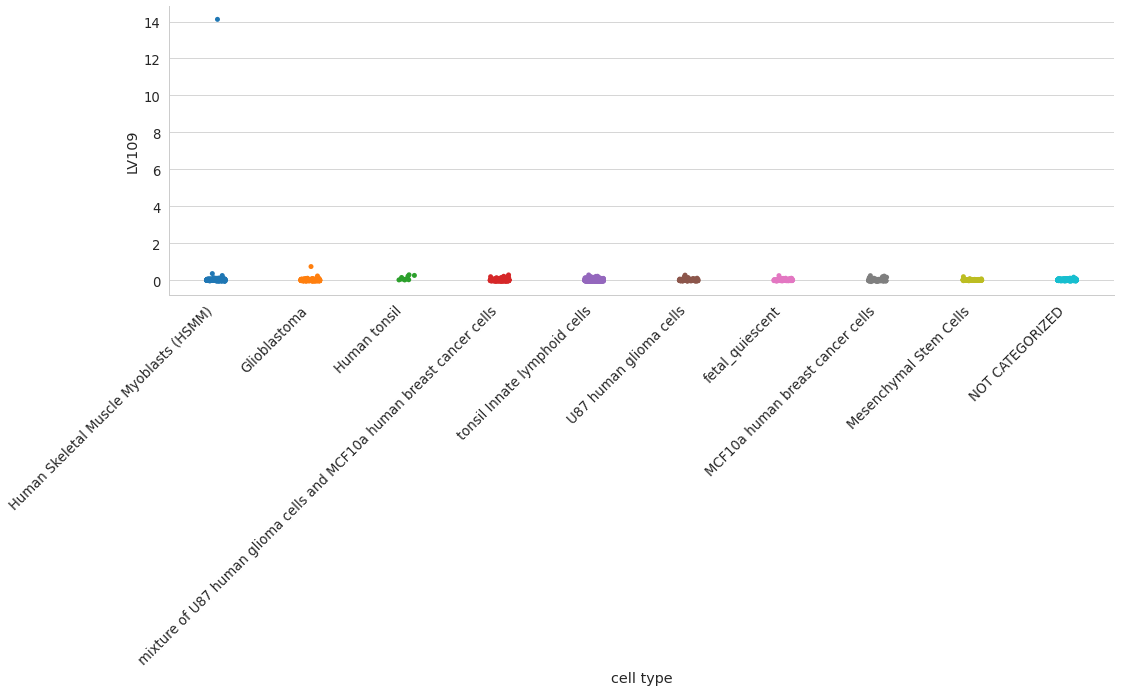

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [36]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("HCT")
    ]
    display(_tmp.head(20))

cell line      LV94
project   run                           
SRP030617 SRR1003789    HCT116  1.211251
          SRR1003784    HCT116  1.046152
SRP063339 SRR2242938    HCT116  1.031260
SRP030617 SRR1003796    HCT116  0.921076
SRP007506 SRR314740    HCT-116  0.917849
SRP063339 SRR2242932    HCT116  0.911211
SRP007506 SRR314741    HCT-116  0.910415
SRP030617 SRR1003795    HCT116  0.905705
SRP062230 SRR2153524    HCT116  0.899509
SRP007506 SRR314739    HCT-116  0.881594
SRP063339 SRR2242926    HCT116  0.879392
SRP030617 SRR1003755    HCT116  0.878342
SRP063339 SRR2242923    HCT116  0.874801
SRP007506 SRR314738    HCT-116  0.870860
SRP030617 SRR1003756    HCT116  0.867322
SRP062230 SRR2153523    HCT116  0.858625
SRP057437 SRR1981008   HCT 116  0.856282
          SRR1981012   HCT 116  0.855181
SRP030617 SRR1003836    HCT116  0.853932
SRP057437 SRR1981011   HCT 116  0.848078

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057205, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP063339"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line                    clone  \
project   run                                             
SRP063339 SRR2242938    HCT116   18qNE Deletion Clone 1   
          SRR2242932    HCT116        E7 Deletion Clone   
          SRR2242926    HCT116           Control Cone 3   
          SRR2242923    HCT116          Control Clone 2   
          SRR2242929    HCT116          Control Clone 4   
          SRR2242934    HCT116        E7 Deletion Clone   
          SRR2242920    HCT116          Control Clone 1   
          SRR2242933    HCT116        E7 Deletion Clone   
          SRR2242940    HCT116   18qNE Deletion Clone 3   
          SRR2242939    HCT116   18qNE Deletion Clone 2   
          SRR2242928    HCT116           Control Cone 3   
          SRR2242930    HCT116          Control Clone 4   
          SRR2242931    HCT116          Control Clone 4   
          SRR2242925    HCT116          Control Clone 2   
          SRR2242921    HCT116          Control Clone 1   
          SRR2242922    HCT116          Control Clone 1   
          SRR2242944    HCT116    18qE Deletion Clone 2   
          SRR2242943    HCT116    18qE Deletion Clone 1   
          SRR2242924    HCT116          Control Clone 2   
          SRR2242941    HCT116          Control Clone 1   
          SRR2242927    HCT116           Control Cone 3   
          SRR2242942    HCT116          Control Conle 2   
          SRR2242947    HEK293  HEK293 Deletion Clone 1   
          SRR2242948    HEK293  HEK293 Deletion Clone 1   
          SRR2242945    HEK293   HEK293 Control Clone 1   
          SRR2242946    HEK293   HEK293 Control Clone 2   

                                  time point      LV94  
project   run                                           
SRP063339 SRR2242938  RNA extracted on day A  1.031260  
          SRR2242932  RNA extracted on day A  0.911211  
          SRR2242926  RNA extracted on day A  0.879392  
          SRR2242923  RNA extracted on day A  0.874801  
          SRR2242929  RNA extracted on day A  0.825395  
          SRR2242934  RNA extracted on day C  0.788623  
          SRR2242920  RNA extracted on day A  0.780620  
          SRR2242933  RNA extracted on day B  0.752707  
          SRR2242940  RNA extracted on day A  0.750509  
          SRR2242939  RNA extracted on day B  0.744037  
          SRR2242928  RNA extracted on day C  0.741833  
          SRR2242930  RNA extracted on day B  0.733982  
          SRR2242931  RNA extracted on day C  0.727599  
          SRR2242925  RNA extracted on day C  0.725582  
          SRR2242921  RNA extracted on day B  0.722573  
          SRR2242922  RNA extracted on day C  0.720534  
          SRR2242944  RNA extracted on day D  0.713727  
          SRR2242943  RNA extracted on day D  0.707055  
          SRR2242924  RNA extracted on day B  0.703623  
          SRR2242941  RNA extracted on day D  0.695928  
          SRR2242927  RNA extracted on day B  0.680938  
          SRR2242942  RNA extracted on day D  0.671486  
          SRR2242947  RNA extracted on day E -0.006264  
          SRR2242948  RNA extracted on day E -0.008022  
          SRR2242945  RNA extracted on day E -0.011703  
          SRR2242946  RNA extracted on day E -0.032402

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.